In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

from collections import defaultdict

from scipy.ndimage import median_filter
from scipy.signal import savgol_filter


In [35]:
# import funcs

%run ./utils.ipynb
%run ./utilsMassProfile.ipynb

In [8]:
Myr_per_Nbody = 0.36627254517014160E+03/ 0.15200000000000000E+03
source = '/cosma5/data/durham/dc-pick2/simulations'
hyades = source + '/Hyades'
hyades

'/cosma5/data/durham/dc-pick2/simulations/Hyades'

In [9]:
path = hyades + '/snap.40_240.h5part'
path

'/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_240.h5part'

In [10]:
with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

        mtot = np.sum(m)



In [6]:
get_com(x, y, z, m)

[np.float32(15.102393), np.float32(-7.5536737), np.float32(0.4713251)]

In [36]:
%timeit -n 100 shrinking_sphere(x, y, z, m, r=25)

3.94 ms ± 21.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [37]:
%timeit -n 100 shrinking_sphere_old(x, y, z, m, r=25, rate=.8)

4.11 ms ± 35.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [15]:
3.86 / 2.88 # speedup

1.3402777777777777

In [24]:
history = []
com = shrinking_sphere(x, y, z, m, history=history, r=25)

history = np.asarray(history)
history

array([[-1032.8811   ,   536.35803  ,    -9.94536  ],
       [-1032.996    ,   536.5436   ,    -8.953743 ],
       [-1033.0446   ,   536.59534  ,    -8.919052 ],
       [-1033.0448   ,   536.6124   ,    -8.905719 ],
       [-1033.0377   ,   536.6391   ,    -8.922215 ],
       [-1033.0337   ,   536.6257   ,    -8.915056 ],
       [-1033.0436   ,   536.60974  ,    -8.919726 ],
       [-1033.0665   ,   536.56744  ,    -8.879981 ],
       [-1033.0502   ,   536.50714  ,    -8.905157 ],
       [-1033.0801   ,   536.4703   ,    -8.976135 ],
       [-1033.0314   ,   536.4592   ,    -8.9841385],
       [-1033.0416   ,   536.49506  ,    -8.99203  ],
       [-1033.0789   ,   536.50244  ,    -9.00507  ],
       [-1033.0309   ,   536.5148   ,    -8.981598 ],
       [-1032.9828   ,   536.5125   ,    -9.004885 ],
       [-1032.9762   ,   536.51624  ,    -9.004794 ],
       [-1032.9524   ,   536.53107  ,    -9.00246  ],
       [-1032.9358   ,   536.4729   ,    -9.038121 ],
       [-1032.945    ,   536

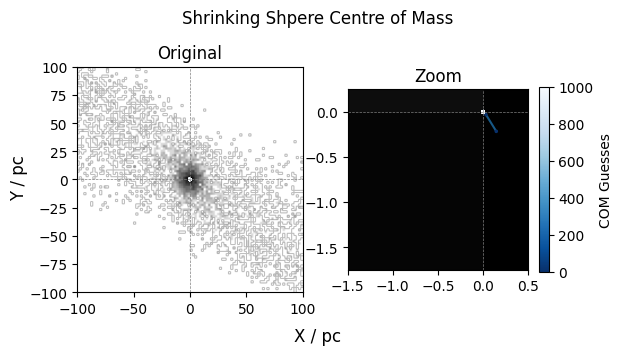

In [22]:
offset = 100
zoom_offset = 1

fig, ax = plt.subplots(1,2)

hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, range=[[-offset, offset], [-offset, offset]])
ax[0].imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)
hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, range=[[-offset, offset], [-offset, offset]])
ax[1].imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)


histx = history.T[0]
histy = history.T[1]

ax[0].plot(histx - com[0], histy - com[1], color='tab:blue', alpha=0.75)
ax[1].plot(histx - com[0], histy - com[1], color='tab:blue', alpha=0.75)

ax[0].scatter(histx - com[0], histy - com[1], label='guesses', marker='.',
                c=range(len(history)), cmap='Blues_r', s=10, zorder=2)
cb = ax[1].scatter(histx - com[0], histy - com[1], label='COM guesses', marker='.',
                c=range(len(history)), cmap='Blues_r', s=10, zorder=2)

plt.colorbar(cb, ax=ax[1], shrink=0.5, label='COM Guesses')


ax[0].set_xlim(-offset, offset)
ax[0].set_ylim(- offset, offset)
ax[0].set_aspect('equal')
ax[0].set_title('Original')


ax[1].set_xlim(-zoom_offset-0.5, zoom_offset-0.5)
ax[1].set_ylim(- zoom_offset-0.75, zoom_offset-0.75)
ax[1].set_aspect('equal')
ax[1].set_title('Zoom')

ax[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax[0].axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax[1].axvline(0, color='gray', linewidth=0.5, linestyle='--')

fig.supxlabel('X / pc', y=0.15)
fig.supylabel('Y / pc')

fig.suptitle('Shrinking Shpere Centre of Mass', y=0.85)

plt.savefig('Images/ShrinkShereCOM.png')
plt.show()

In [333]:
#USE ME FOR MASS PROFILES
%timeit shrinking_sphere(x, y, z, m, r=100)

3.85 ms ± 172 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [9]:
fractions = np.asarray([0.75, 0.5, 0.25])
frac_mass_radii = find_bounding_radii(x, y, z, m, fractions)
frac_mass_radii

array([99.99002  , 28.555422 ,  7.4819603], dtype=float32)

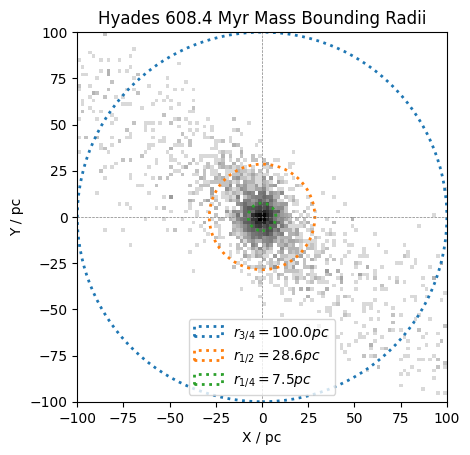

In [10]:
offset = 100
frac_lables = ['3/4', '1/2', '1/4']
lables = [fr'$r_{{{l}}}={v:.1f}pc$' for l, v in zip(frac_lables, frac_mass_radii)]
          
colours = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots()

hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, 
                                      range=[[-offset, offset], [-offset, offset]])
ax.imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)

for r, label, colour in zip(frac_mass_radii, lables, colours):
    r_mass_radius = Circle((0,0), r, fill=False, linestyle='dotted',
                           color=colour, label=label, linewidth=2)
    ax.add_artist(r_mass_radius)



ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title(f'Hyades {t:.1f} Myr Mass Bounding Radii')
ax.set_xlabel('X / pc')
ax.set_ylabel('Y / pc')
ax.set_xlim(-offset, offset)
ax.set_ylim(- offset, offset)
ax.set_aspect('equal')
plt.legend()

plt.show()


In [11]:
fractions = np.asarray([0.75, 0.5, 0.25])
results = []
times = []

for snap in [0, 60, 120, 180, 240]:
    path = hyades + f'/snap.40_{snap}.h5part'

    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

        frac_mass_radii = find_bounding_radii(x, y, z, m, fractions)
        results.append(frac_mass_radii)
        times.append(t)

    
results = np.asarray(results)
times = np.asarray(times)




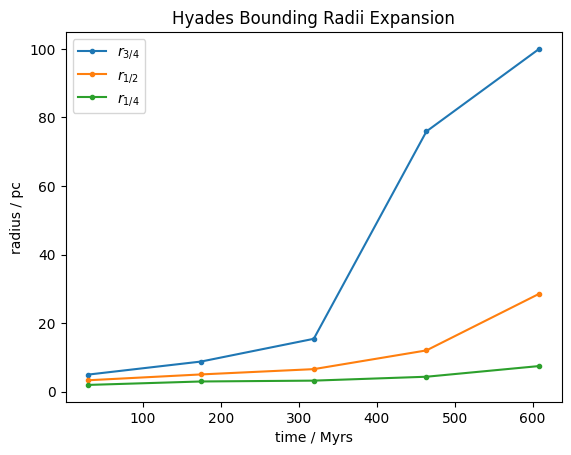

In [12]:
frac_lables = ['3/4', '1/2', '1/4']
lables = [fr'$r_{{{l}}}$' for l in frac_lables]

fig, ax = plt.subplots()

for i, (label, colour) in enumerate(zip(lables, colours)):
    ax.plot(times, results.T[i], label=label, color=colour, marker='.')

ax.set_xlabel('time / Myrs')
ax.set_ylabel('radius / pc')

#ax.set_yscale('log')

plt.title("Hyades Bounding Radii Expansion")
plt.legend()
plt.show()
 

In [13]:
results.T[0]

array([ 4.993082,  8.79833 , 15.429023, 75.92934 , 99.99002 ],
      dtype=float32)

In [46]:
times = [0,100,200,300,400,500]

data, glob_df, Myr_per_Nbody = get_steps_at_times(hyades, times)


mass_profiles = find_mass_profiles(data)


/tmp/ipykernel_3459190/3720612914.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)


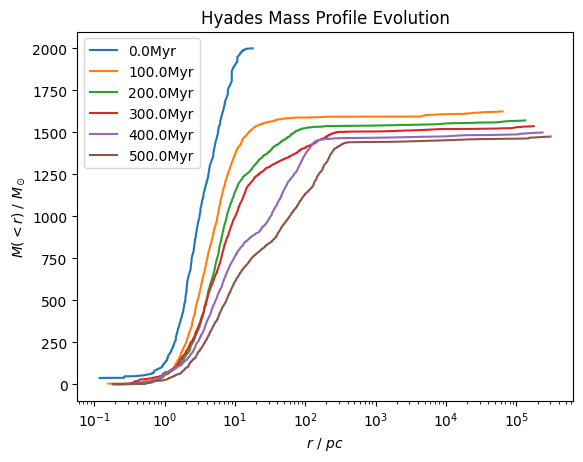

In [58]:
fig, ax = plt.subplots()
plot_mass_profile(fig, ax, mass_profiles, title='Hyades Mass Profile Evolution')
plt.show()

In [299]:
times = [0]
experiment_path = source + '/Concentration'

runs_data = get_runs_data(experiment_path, times)

runs_mass_profiles = find_mass_profiles_experiment(runs_data)


/tmp/ipykernel_2721214/1385138055.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_2721214/1385138055.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_2721214/1385138055.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_2721214/1385138055.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_2721214/1385138055.py:27: ParserWarning: Length of header or names does not match len

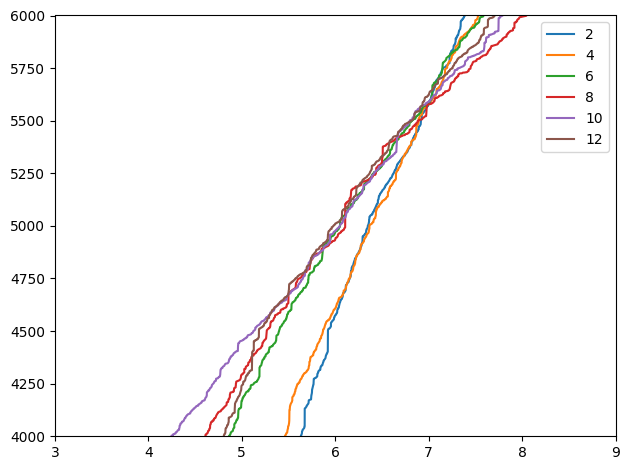

In [311]:
ncols = 3
nrows = int(np.ceil(len(runs_data) / ncols))
fig, ax = plt.subplots()

#plot_mass_profiles(fig, axes, runs_mass_profiles, titlehead=r'$W_0$ = ')

for run, mass_profiles in runs_mass_profiles.items():
    for time, (r_sort, _, m_sums) in mass_profiles.items():
        ax.plot(r_sort, m_sums, label=run)

ax.set_xlim([3,9])
ax.set_ylim([4000,6000])

plt.legend()
axes[0][0].legend(fontsize=6)
plt.tight_layout()
plt.show()

In [5]:
times = np.logspace(np.log10(1), np.log10(600), num=10)
experiment_path = source + '/Concentration'

runs_data = get_runs_data(experiment_path, times)

runs_mass_profiles = find_mass_profiles_experiment(runs_data)

/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length o

AttributeError: 'numpy.ndarray' object has no attribute 'set_yscale'

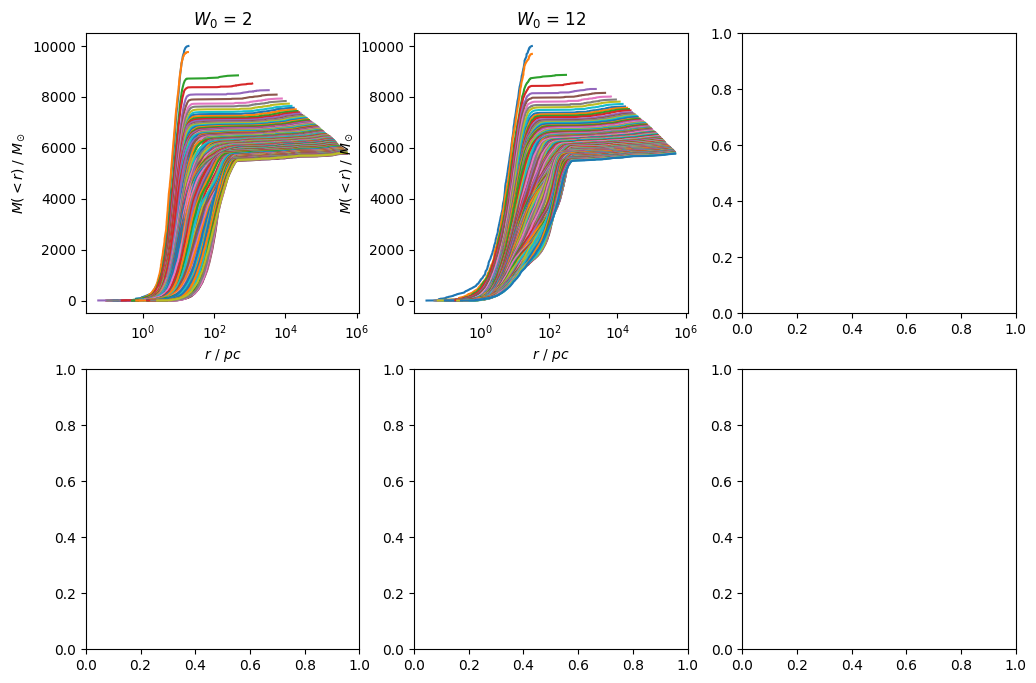

In [312]:
ncols = 3
nrows = int(np.ceil(len(runs_data) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))

plot_mass_profiles(fig, axes, runs_mass_profiles_w0, titlehead=r'$W_0$ = ')

for ax in axes:
    ax.set_yscale('log')

axes[0][0].legend(fontsize=6)
plt.tight_layout()
plt.show()

# change to be panells with the different runs then use different pannels to show different times
# sub panel showing ratios of the lines compares to W0=6

In [9]:
times = np.logspace(np.log10(1), np.log10(600), num=10)
experiment_path = source + '/Mass'

runs_data = get_runs_data(experiment_path, times)

runs_mass_profiles = find_mass_profiles_experiment(runs_data)

/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length o

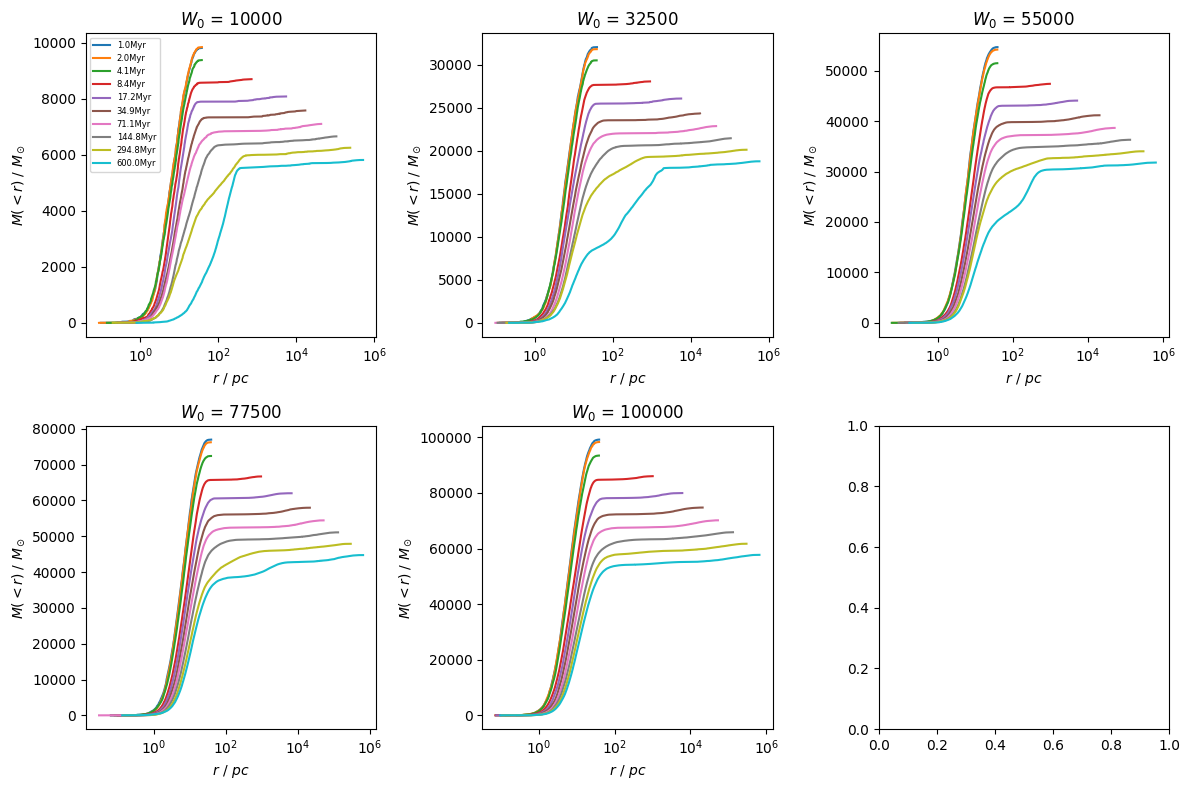

In [10]:
ncols = 3
nrows = int(np.ceil(len(runs_data) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))

plot_mass_profiles(fig, axes, runs_mass_profiles, titlehead=r'$M$ = ')

axes[0][0].legend(fontsize=6)
plt.tight_layout()
plt.show()

compute and store

In [114]:
bounding_df_by_experiment = {}

In [248]:
fractions = np.asarray([0.9, 0.5, 0.25])
runs = [2, 12]

experiment_path = source + '/Concentration'

runs_data_w0 = get_runs_data(experiment_path, runs=runs, step_interval=10)

runs_mass_profiles_w0 = find_mass_profiles_experiment(runs_data_w0)

bounding_df_by_experiment['W_0']  = find_all_bounding_radiis(runs_mass_profiles_w0, fractions)

/tmp/ipykernel_2721214/1385138055.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)


In [121]:
store_all_bounding_radiis(source + '/Concentration/bounding_rads.h5', bounding_df_by_experiment['W_0'])

ImportError: `Import pytables` failed.  Use pip or conda to install the pytables package.

In [249]:
fractions = np.asarray([0.9, 0.5, 0.25])
runs = [10000,100000]

experiment_path = source + '/Mass'

runs_data_m = get_runs_data(experiment_path, runs=runs, step_interval=10)

runs_mass_profiles_m = find_mass_profiles_experiment(runs_data_m)

bounding_df_by_experiment['M'] = find_all_bounding_radiis(runs_mass_profiles_m, fractions)

/tmp/ipykernel_2721214/1385138055.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)


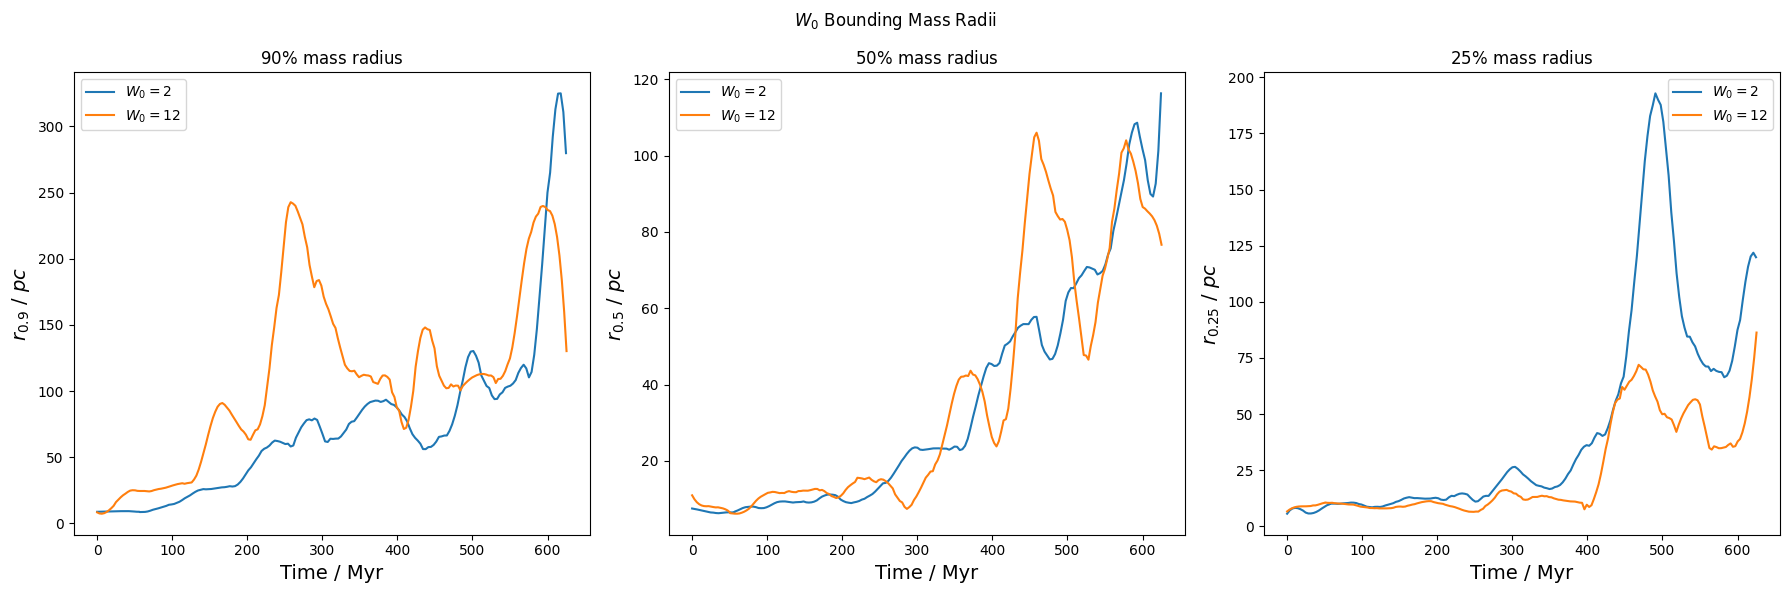

In [261]:
fig, axes = plt.subplots(1, len(fractions), figsize=(6*len(fractions), 6))
run_label = 'W_0'
median_width = 50 # Myr
savgol_width = 50
runs = [2, 12]

for run, df in bounding_df_by_experiment[run_label].items():
    if run not in runs:
        continue

    median_window = int(round(median_width / np.median(np.diff(df['time']))))
    savgol_window = int(round(savgol_width / np.median(np.diff(df['time']))))

    
    radii_clipped = median_filter(df[fractions], size=(median_window, 1))

    radii_smooth = savgol_filter(radii_clipped, savgol_window, 3, axis=0)

    for i, frac in enumerate(fractions):
        axes[i].plot(df['time'], radii_smooth[:, i], label=fr'${run_label}={run}$')
        axes[i].set_title(fr'${100*frac:.0f}\%$ mass radius')
        axes[i].set_xlabel('Time / Myr', fontsize=14)
        axes[i].set_ylabel(fr'$r_{{{frac}}}\ /\ pc$', fontsize=14)
        axes[i].legend()
        #axes[i].set_yscale('log')

        #axes[i].set_ylim([1,400])

plt.suptitle(fr'${{{run_label}}}$ Bounding Mass Radii')
plt.tight_layout()
plt.savefig(f'Images/{run_label}_mass_radii.png')
plt.show()

### $r_{1/4}$ 
- $W_0$=2 peaks a lot higher than 12
- core collapse happening faster in $W_0$=12
- stays relatively stable until rapidly increasing at ~400Myr

### $r_{1/2}$ 
- relatively consistent accross $W_0$
- high concentration seems to be more sensitive to oscilations

### $r_{9/10}$
- clear oscilations that line up with ~200Myr orbital period
- $W_0$=2 less sensitive to them than higher concentration
- low $W_0$ seems to grow exponentially, compared to a more constant rate at high concentration

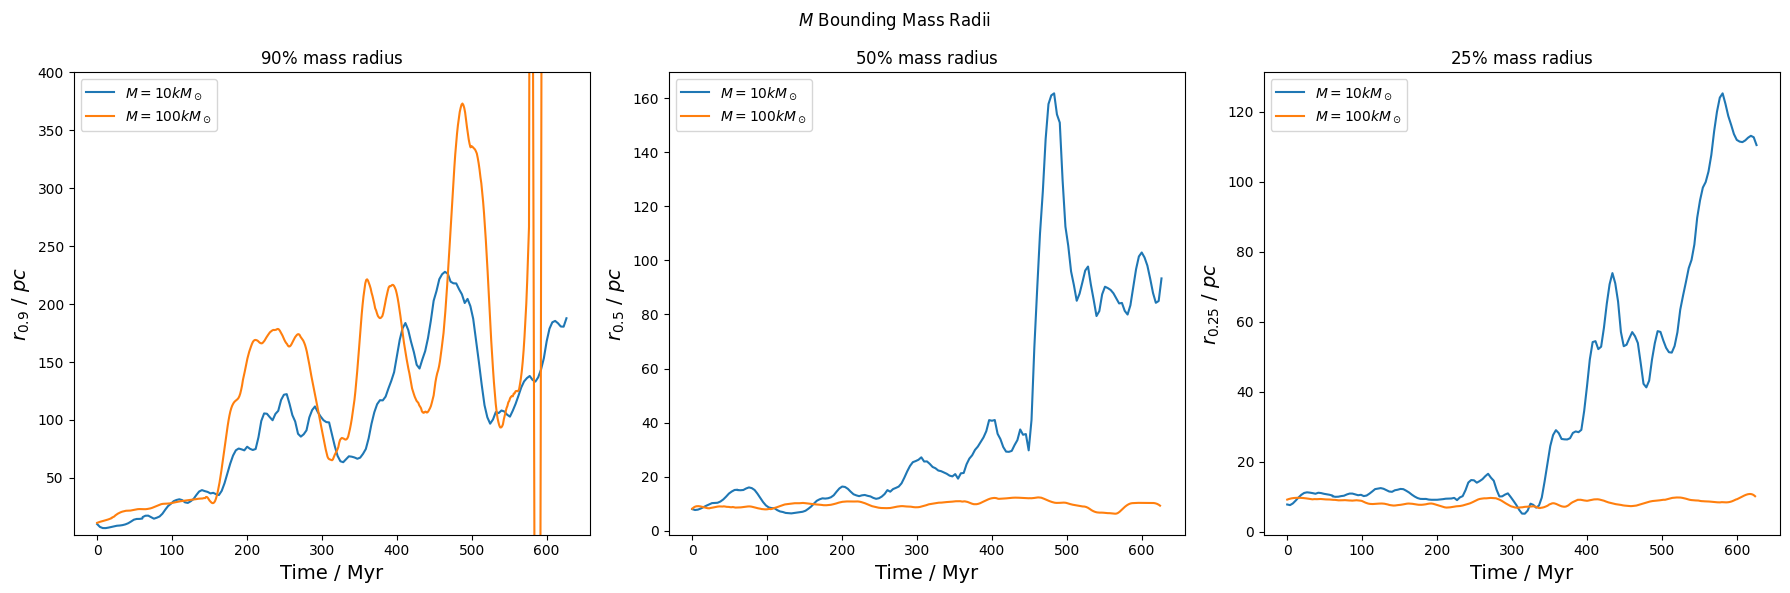

In [251]:
fig, axes = plt.subplots(1, len(fractions), figsize=(6*len(fractions), 6))
run_label = 'M'
median_width = 50 # Myr
savgol_width = 50
runs = [10000,100000]

for run, df in bounding_df_by_experiment[run_label].items():
    if run not in runs:
        continue

    median_window = int(round(median_width / np.median(np.diff(df['time']))))
    savgol_window = int(round(savgol_width / np.median(np.diff(df['time']))))

    
    radii_clipped = median_filter(df[fractions], size=(median_window, 1))

    radii_smooth = savgol_filter(radii_clipped, savgol_window, 4, axis=0)

    for i, frac in enumerate(fractions):
        axes[i].plot(df['time'], radii_smooth[:, i], label=fr'${run_label}={run/1000:.0f}kM_\odot$')
        axes[i].set_title(fr'${100*frac:.0f}\%$ mass radius')
        axes[i].set_xlabel('Time / Myr', fontsize=14)
        axes[i].set_ylabel(fr'$r_{{{frac}}}\ /\ pc$', fontsize=14)
        axes[i].legend()
        #axes[i].set_yscale('log')

axes[0].set_ylim([1,400])

plt.suptitle(fr'${{{run_label}}}$ Bounding Mass Radii')
plt.tight_layout()
plt.savefig(f'Images/{run_label}_mass_radii.png')
plt.show()

# try doing a 1000 sol mass run

### $r_{1/4}$ 
- stays almost flat for high M but dissolves for low M
- high M will have a stronger pull so its harder to strip

### $r_{1/2}$ 
- similar to 1/4 but low M has a large singe event disruption instead of a more gradual change which then falls back down
- more tidal shock?
- mass seems to massively influence 1/4 and 1/2 mass evolution, makes sense

### $r_{9/10}$
- struggled to completely remove noise here without completely smoothing out the data
- both follow a similar shape, corrolating with apocentre
- high M expands out further compared to low M

only the higher orbitals seem to be getting stripped in high M compared to an overall expansion in low M

mass seems to have secondarry effect on external stripping compared to tidal effects

In [241]:
r90br50 = {experiment : 
           {run : 
            bounding_df[0.9] / bounding_df[0.5] for run, bounding_df in bounding_df_by_run.items()}
           for experiment, bounding_df_by_run in bounding_df_by_experiment.items()}

(179,)
(201,)
(168,)
(522,)


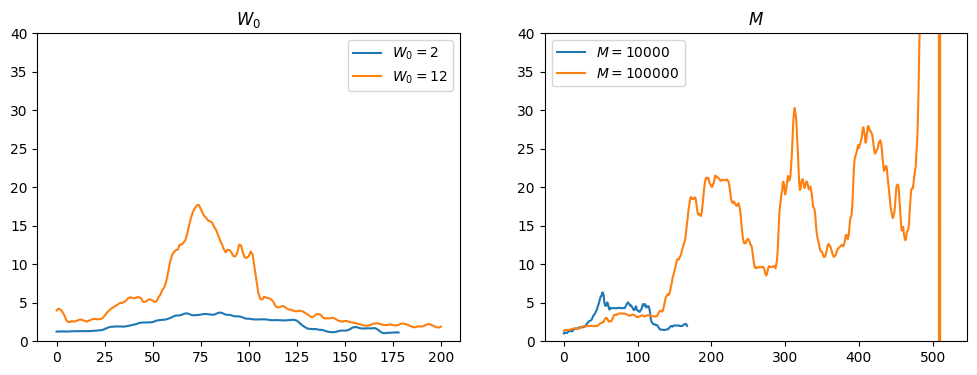

In [243]:
cols = len(r90br50.keys())
fig, axes = plt.subplots(1,cols, figsize=(6*cols, 4))

for (experiment, r90br50_by_run), ax in zip(r90br50.items(), axes):
    for run, ratio in r90br50_by_run.items():    
        print(ratio.shape)
        ratio_clipped = median_filter(ratio, size=50)
    
        ratio_smooth = savgol_filter(ratio_clipped, 10, 4, axis=0)
        
        ax.plot(ratio_smooth, label=fr'${{{experiment}}}={{{run}}}$')

        #ax.set_yscale('log')
        ax.set_ylim([0,40])
        ax.legend()

    ax.set_title(fr'${{{experiment}}}$')
    

/tmp/ipykernel_2721214/3024974260.py:11: RuntimeWarning: divide by zero encountered in divide
  periods = 1/freqs


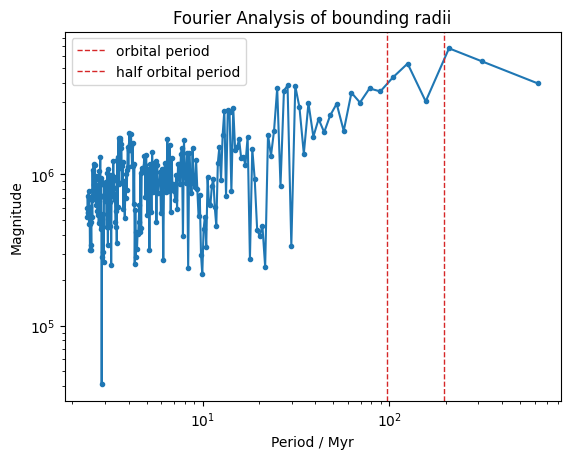

In [315]:
experiment = bounding_df_by_experiment['M'][100000]

dt = np.mean(np.diff(experiment['time']))

signal = experiment[0.9]


fft = np.fft.rfft(signal)

freqs = np.fft.rfftfreq(len(signal), d=dt)
periods = 1/freqs

fig, ax = plt.subplots()
ax.plot(periods, np.abs(fft), marker='.')
ax.set_xlabel("Period / Myr")
ax.set_ylabel("Magnitude")

ax.set_yscale('log')
ax.set_xscale('log')

ax.axvline(195, color='tab:red', linestyle='--', linewidth=1, label='orbital period')
ax.axvline(195/2, color='tab:red', linestyle='--', linewidth=1, label='half orbital period')
ax.set_title("Fourier Analysis of bounding radii")

ax.legend()

plt.show()